## Experiments - Weather
This is an augmentation of the document "experiments.ipynb" by Natalia Soares, where in addition to her added experiments, weather-based prediction algorithms and cases were included to improve the accuracy of the prediction model. This work was done by Tolga Akcay for the 2026 Master's Thesis "Aircraft Trajectory Prediction Using Continuous Data in 4D Grids".  

In [84]:
import configparser
import os
import pyproj
import json

from dotenv import load_dotenv
from pathlib import Path
from typing import Literal

import h3
import numpy as np
from shapely import Polygon
from geojson import Feature, FeatureCollection

import plotly.express as px
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd

from sklearn.metrics.pairwise import haversine_distances
from math import radians

import torch
import torch.nn as nn
import random
from torchinfo import summary

config = configparser.ConfigParser()
config.read("./src/secrets.conf")

from src.data.dataloader import TrajectoryDataModule
from src.data.schemas import (
    trajectories_schema,
    flight_categories_schema,
    temporal_categories_schema,
    non_seq_numerical_schema,
    sequential_weather_schema,
    training_trajectories_schema,
    training_trajectories_with_latlon_schema,
    training_trajectories_with_xy_schema
)

# Experiment Setup

In [85]:
GEODATA_REPRESENTATION : Literal["h3", "xy", "latlon"] = "h3"
H3_RESOLUTION : Literal["5", "6", "7", "8", "9", "10", "11"] = "5"
IN_SEQ_LEN = 5 #Fixed
TGT_SEQ_LEN = 60 #Fixed
SAMPLING_TIME = 60 #Fixed

# Experiment

In [86]:
AIRPORT = "LFBO"
START = "2024-10-1"
END = "2024-11-6"
USE_WEATHER = True  
WEATHER_DATA_PATH = "./src/data/weather/trajectory_weather_features_2024-10-1_2024-11-6.parquet" if USE_WEATHER else None  #Change to OG Code - Weather Data Added

WEATHER_FEATURE_SET: Literal["full", "reduced"] = "reduced" #Used to reduce from 6 weather features to 3. The 3 features are along-track wind, wind magnitude, ISA-deviation temperature, based on Hodgkin et al.
REDUCED_WEATHER_COLUMNS = ["along_track_mean", "wind_mag_grad", "isa_dev_mean"]
SEQ_WEATHER_COLUMNS = (
    (REDUCED_WEATHER_COLUMNS if WEATHER_FEATURE_SET == "reduced" else list(sequential_weather_schema.keys()))
    if USE_WEATHER else None
)

DATA_SOURCE = Path('./src/data/raw')

MODEL_CKP_PATH = './src/models/checkpoints'
BATCH_SIZE = 64

MAX_LAT = 90.               # degrees
MAX_LON = 180.              # degrees
MAX_ALTITUDE = 43100        # ft
MAX_SPEED = 600             # knots
MAX_TRACK = 360             # degrees
MAX_RATE = 3000             # ft./min

MIN_LAT = -90.
MIN_LON = -180.
MIN_ALTITUDE = 0.0
MIN_RATE = -MAX_RATE
MIN_SPEED = 0.0
MIN_TRACK = 0.0
EARTH_RADIUS_M = 6378000

TRAJECTORY_COLUMNS = list(trajectories_schema.keys())
CATEGORY_COLUMNS = list(flight_categories_schema.keys())
WEATHER_COLUMNS = list(non_seq_numerical_schema.keys())
TEMPORAL_COLUMNS = list(temporal_categories_schema.keys())

if GEODATA_REPRESENTATION == "latlon":
    TRAINING_COLUMNS = list(training_trajectories_with_latlon_schema.keys())
elif GEODATA_REPRESENTATION == "xy":
    TRAINING_COLUMNS = list(training_trajectories_with_xy_schema.keys())
else: # Default use h3
    TRAINING_COLUMNS = list(training_trajectories_schema.keys())
TRAINING_COLUMNS


['h3_cell', 'altitude', 'diff_time']

In [87]:
#Change to OG Code - pyproj.transform is removed in pyproj 3.x, use Transformer.from_crs instead, built once rather than per call
_GPS_TO_ECEF_TRANSFORMER = pyproj.Transformer.from_crs("EPSG:4326", "EPSG:4978", always_xy=True)
_ECEF_TO_GPS_TRANSFORMER = pyproj.Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

def gps_to_ecef(lat, lon, alt):
    x, y, z = _GPS_TO_ECEF_TRANSFORMER.transform(lon, lat, alt)
    return pd.Series([x, y, z])

def ecef_to_gps(x, y, z):
    lon, lat, h = _ECEF_TO_GPS_TRANSFORMER.transform(x, y, z)
    return lat, lon, h
 
def get_geo_distance(
        origin: tuple[float, float],
        destination: tuple[float, float],
        unit: Literal["km", "m"] = "km",
    ) -> float:

    origin_in_radians = [radians(deg_coord) for deg_coord in origin]
    destination_in_radians = [radians(deg_coord) for deg_coord in destination]
    result = haversine_distances([origin_in_radians, destination_in_radians])
    result = result[np.where(result != 0.)]
    if not isinstance(result, float):
        if len(result) == 0:
            result = 0.0
        else:
            result = result[0]
    if unit == "km":
        return result * EARTH_RADIUS_M / 1000
    return result * EARTH_RADIUS_M

In [88]:
def h3_to_polygon(cell):
    coords = h3.cell_to_boundary(cell)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)

def hexagons_dataframe_to_geojson(df_hex, hex_id_field, geometry_field, value_field, file_output = None):
    list_features = []
    for i, row in df_hex.iterrows():
        feature = Feature(
            geometry = row[geometry_field],
            id = row[hex_id_field],
            properties = {"value": row[value_field]},
        )
        list_features.append(feature)

    feat_collection = FeatureCollection(list_features)
    if file_output is not None:
        with open(file_output, "w") as f:
            json.dump(feat_collection, f)
    else :
      return feat_collection

def get_geojson_df(df, id_column="flight_id", h3_cell_column="h3_cell"):
    df["h3_geometry"] = df[h3_cell_column].apply(lambda x: h3_to_polygon(x))

    g_df = (
        df[[id_column, h3_cell_column, "h3_geometry"]]
        .groupby(h3_cell_column)
        .agg({id_column: set, "h3_geometry": "first"})
        .reset_index()
    )
    g_df["num_flights"] = g_df[id_column].apply(lambda row: len(row))


    return g_df, hexagons_dataframe_to_geojson(
        g_df,
        h3_cell_column,
        "h3_geometry",
        "num_flights"
    )

In [89]:
data_module = TrajectoryDataModule(
    dataset_kwargs={
        "airport": AIRPORT,
        "start": START,
        "end": END,
        "input_len": IN_SEQ_LEN,
        "target_len": TGT_SEQ_LEN,
        "data_source": DATA_SOURCE,
        "sampling_time": SAMPLING_TIME,
        "h3_resolution": H3_RESOLUTION,
        "training_columns": TRAINING_COLUMNS,
        "weather_data_path": WEATHER_DATA_PATH,  #Change to OG Code - None when USE_WEATHER is False, fully backward compatible
        "weather_columns": SEQ_WEATHER_COLUMNS,  #Change to OG Code - full 6-feature or reduced 3-feature set (see config cell); None is fine, TrajectoryDataModule falls back to the full set when the key is absent, but None here is only ever paired with WEATHER_DATA_PATH=None (use_weather False), so it's inert
    },
    batch_size=BATCH_SIZE,
)

[{'year': 2024, 'month': 10, 'day': 1}, {'year': 2024, 'month': 10, 'day': 2}, {'year': 2024, 'month': 10, 'day': 3}, {'year': 2024, 'month': 10, 'day': 4}, {'year': 2024, 'month': 10, 'day': 5}, {'year': 2024, 'month': 10, 'day': 6}, {'year': 2024, 'month': 10, 'day': 7}, {'year': 2024, 'month': 10, 'day': 8}, {'year': 2024, 'month': 10, 'day': 9}, {'year': 2024, 'month': 10, 'day': 10}, {'year': 2024, 'month': 10, 'day': 11}, {'year': 2024, 'month': 10, 'day': 12}, {'year': 2024, 'month': 10, 'day': 13}, {'year': 2024, 'month': 10, 'day': 14}, {'year': 2024, 'month': 10, 'day': 15}, {'year': 2024, 'month': 10, 'day': 16}, {'year': 2024, 'month': 10, 'day': 17}, {'year': 2024, 'month': 10, 'day': 18}, {'year': 2024, 'month': 10, 'day': 19}, {'year': 2024, 'month': 10, 'day': 20}, {'year': 2024, 'month': 10, 'day': 21}, {'year': 2024, 'month': 10, 'day': 22}, {'year': 2024, 'month': 10, 'day': 23}, {'year': 2024, 'month': 10, 'day': 24}, {'year': 2024, 'month': 10, 'day': 25}, {'year':

DEBUG:src.data.dataloader:Num training flights: 873
DEBUG:src.data.dataloader:Num validation flights: 249
DEBUG:src.data.dataloader:Num test flights: 124


In [90]:
train_flight_ids = []
for _,_,ids,_,_,_ in data_module.train_dataloader():  #Change to OG Code - pad_collate now returns 6 items (added wx_enc, wx_dec)
    train_flight_ids.extend(ids)

val_flight_ids = []
for _,_,ids,_,_,_ in data_module.val_dataloader():
    val_flight_ids.extend(ids)

test_flight_ids = []
for _,tgt,ids,_,_,_ in data_module.test_dataloader():
    test_flight_ids.extend(ids)

In [91]:
df = data_module.data.data.to_pandas()

In [92]:
data_train = df.loc[df.flight_id.isin(train_flight_ids)]
data_train["type"] = "train"

data_val = df.loc[df.flight_id.isin(val_flight_ids)]
data_val["type"] = "val"

data_test = df.loc[df.flight_id.isin(test_flight_ids)]
data_test["type"] = "test"

data = pd.concat([data_train, data_val, data_test])

g_df, geojson_obj = get_geojson_df(data)

#Change to OG Code - hover_data extended with altitude, and weather when USE_WEATHER is on. The
#weather columns (wind_speed_ms, wind_direction_deg, temperature_C) only exist in `data` when
#_attach_weather_features actually ran - it's a no-op when USE_WEATHER is False, so listing them
#unconditionally broke the no-weather path with a "not the name of a column" ValueError.
hover_cols = ["flight_id", "timestamp", "gps_altitude"]
if USE_WEATHER:
    hover_cols += ["wind_speed_ms", "wind_direction_deg", "temperature_C"]

h3_traj = px.choropleth_mapbox(
    data,
    geojson=geojson_obj,
    locations="h3_cell",
    color="type",
    hover_data=hover_cols,
    zoom=0,
    opacity=0.3,
)

geo_traj = px.scatter_mapbox(
    data,
    lat="latitude",
    lon="longitude",
    hover_data=hover_cols,
    color="type",
    zoom=0
)

fig = go.Figure(h3_traj)
fig.add_traces(list(geo_traj.select_traces()))
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.update_layout(title="Flights paths", mapbox_style="open-street-map")
fig.write_html("./plots/train_val_test_paths_noweather_011024_061124.html")  #Change to OG Code - _weather suffix so this run does not overwrite a non-weather plot

/tmp/ipykernel_265512/646814436.py:22: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  h3_traj = px.choropleth_mapbox(
/tmp/ipykernel_265512/646814436.py:32: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  geo_traj = px.scatter_mapbox(


In [93]:
if "latitude" in TRAINING_COLUMNS:
  EXPERIMENT_NAME = f"latlon_{SAMPLING_TIME}_{IN_SEQ_LEN}_{TGT_SEQ_LEN}"
  #Change to OG Code - append a weather flag so a weather run cannot overwrite a baseline checkpoint
  EXPERIMENT_NAME += "_weather" if USE_WEATHER else ""
  VOCABS_SIZES =[
        len(data_module.data.vocabs["latitude"]),
        len(data_module.data.vocabs["longitude"]),
        len(data_module.data.vocabs["altitude"]),
        len(data_module.data.vocabs["diff_time"])
    ]
elif "x" in TRAINING_COLUMNS:
  EXPERIMENT_NAME = f"xy_{SAMPLING_TIME}_{IN_SEQ_LEN}_{TGT_SEQ_LEN}"
  #Change to OG Code - append a weather flag so a weather run cannot overwrite a baseline checkpoint
  EXPERIMENT_NAME += "_weather" if USE_WEATHER else ""
  VOCABS_SIZES =[
        len(data_module.data.vocabs["x"]),
        len(data_module.data.vocabs["y"]),
        len(data_module.data.vocabs["altitude"]),
        len(data_module.data.vocabs["diff_time"])
    ]
else:
  # Change to OG Code: include date range so different-period runs don't overwrite each other's checkpoints
  EXPERIMENT_NAME = f"h3_{SAMPLING_TIME}_{H3_RESOLUTION}_{IN_SEQ_LEN}_{TGT_SEQ_LEN}_{START}_{END}"
  #Change to OG Code - append a weather flag so a weather run cannot overwrite a baseline checkpoint
  EXPERIMENT_NAME += "_weather" if USE_WEATHER else ""
  VOCABS_SIZES =[
        len(data_module.data.vocabs["h3_cell"]),
        len(data_module.data.vocabs["altitude"]),
        len(data_module.data.vocabs["diff_time"])
    ]
#Change to OG Code - reduced-feature-set runs get their own tag so they can't overwrite the
#full-feature-set checkpoint/plots; "full" keeps the existing "_weather" name unchanged
EXPERIMENT_NAME += "_reduced" if (USE_WEATHER and WEATHER_FEATURE_SET == "reduced") else ""
EXPERIMENT_NAME

'h3_60_5_5_60_2024-10-1_2024-11-6_weather_reduced'

In [94]:
class EarlyStopper:
    def __init__(self, patience=1, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_validation_loss = float(np.inf)

    def early_stop(self, validation_loss):
        if validation_loss < self.min_validation_loss:
            self.min_validation_loss = validation_loss
            self.counter = 0
        elif validation_loss > (self.min_validation_loss + self.min_delta):
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

In [95]:
class TrajectoryPredictor(nn.Module):
    def __init__(
            self,
            embed_size,
            hidden_size,
            vocabs_sizes,
            dropout_p=0.2,
            output_features=4,
            tgt_seq_len=TGT_SEQ_LEN,
            num_enc_layers = 1,
            num_dec_layers = 2,
            weather_vocabs_sizes=None,  #Change to OG Code - one vocab size per engineered weather feature; None/[] means no weather
        ):
        super(TrajectoryPredictor, self).__init__()
        self.embed_size = embed_size
        self.vocabs_sizes = vocabs_sizes
        self.tgt_seq_len = tgt_seq_len
        self.output_features = output_features
        self.hidden_size = hidden_size
        self.num_enc_layers = num_enc_layers
        self.num_dec_layers = num_dec_layers

        self.embed_1 = nn.Embedding(num_embeddings=self.vocabs_sizes[0], embedding_dim=self.embed_size)
        self.embed_2 = nn.Embedding(num_embeddings=self.vocabs_sizes[1], embedding_dim=self.embed_size)
        self.embed_3 = nn.Embedding(num_embeddings=self.vocabs_sizes[2], embedding_dim=self.embed_size)

        self.layernorm_1 = nn.LayerNorm(normalized_shape=self.embed_size)
        self.layernorm_2 = nn.LayerNorm(normalized_shape=self.hidden_size)
        self.layernorm_3 = nn.LayerNorm(normalized_shape=self.vocabs_sizes[0])
        self.layernorm_4 = nn.LayerNorm(normalized_shape=self.vocabs_sizes[1])
        self.layernorm_5 = nn.LayerNorm(normalized_shape=self.vocabs_sizes[2])

        self.lstm_enc = nn.LSTM(input_size=self.embed_size, hidden_size=self.hidden_size, num_layers=self.num_enc_layers )
        self.lstm_dec = nn.LSTM(input_size=self.embed_size, hidden_size=self.hidden_size, num_layers=self.num_dec_layers)

        self.dense_1 = nn.Linear(in_features=self.hidden_size, out_features=self.vocabs_sizes[0])
        self.dense_2 = nn.Linear(in_features=self.hidden_size, out_features=self.vocabs_sizes[1])
        self.dense_3 = nn.Linear(in_features=self.hidden_size, out_features=self.vocabs_sizes[2])

        if len(self.vocabs_sizes) > 3:
          self.embed_4 = nn.Embedding(num_embeddings=self.vocabs_sizes[3], embedding_dim=self.embed_size)
          self.layernorm_6 = nn.LayerNorm(normalized_shape=self.vocabs_sizes[3])
          self.dense_4 = nn.Linear(in_features=self.hidden_size, out_features=self.vocabs_sizes[3])

        #Change to OG Code - weather embeddings: one nn.Embedding per engineered feature, concatenated
        #into the encoder AND decoder sequence (see forward) but with no dense_N/layernorm/loss head,
        #so weather can never be predicted, only conditioned on (CLAUDE.md "encoded, never decoded")
        self.weather_vocabs_sizes = weather_vocabs_sizes or []
        self.embed_wx = nn.ModuleList([
            nn.Embedding(num_embeddings=vs, embedding_dim=self.embed_size) for vs in self.weather_vocabs_sizes
        ])

        self.dropout = nn.Dropout(dropout_p)
        self.log_softmax = nn.LogSoftmax(dim=2)


    def forward(
            self,
            x_1,
            y_1,
            x_2=None,
            y_2=None,
            x_3=None,
            y_3=None,
            x_4=None,
            y_4=None,
            x_wx=None,  #Change to OG Code - (seq_len, n_weather_features, batch), same convention as x_1..x_4
            y_wx=None,

        ):
        x = self.embed_1(x_1.to(torch.int32))
        if x_2 is not None:
            x_2 = self.embed_2(x_2.to(torch.int32))
            x = torch.cat((x, x_2), dim=0)
        if x_3 is not None:
            x_3 = self.embed_3(x_3.to(torch.int32))
            x = torch.cat((x, x_3), dim=0)
        if x_4 is not None:
            x_4 = self.embed_4(x_4.to(torch.int32))
            x = torch.cat((x, x_4), dim=0)
        if x_wx is not None:
            #Change to OG Code - embed each weather sub-feature and append to the encoder sequence, same dim=0 concatenation as the existing features
            for i, x_wx_i in enumerate(torch.split(x_wx, 1, dim=1)):
                x = torch.cat((x, self.embed_wx[i](x_wx_i.to(torch.int32))), dim=0)
        x = x.squeeze(dim=1)
        x = self.layernorm_1(x)

        x, encoder_state = self.lstm_enc(x)

        y = self.embed_1(y_1.to(torch.int32))
        if y_2 is not None:
            y_2 = self.embed_2(y_2.to(torch.int32))
            y = torch.cat((y, y_2), dim=0)
        if y_3 is not None:
            y_3 = self.embed_3(y_3.to(torch.int32))
            y = torch.cat((y, y_3), dim=0)
        if y_4 is not None:
            y_4 = self.embed_4(y_4.to(torch.int32))
            y = torch.cat((y, y_4), dim=0)
        y_wx_len = 0  #Change to OG Code - tracks the size of the trailing weather block so it can be split off and discarded below
        if y_wx is not None:
            for i, y_wx_i in enumerate(torch.split(y_wx, 1, dim=1)):
                embedded = self.embed_wx[i](y_wx_i.to(torch.int32))
                y = torch.cat((y, embedded), dim=0)
                y_wx_len += embedded.size(0)
        y = y.squeeze(dim=1)
        y = self.layernorm_1(y)

        y, _ = self.lstm_dec(
            y,
            (
                encoder_state[0].repeat(self.num_dec_layers, 1, 1),
                encoder_state[1].repeat(self.num_dec_layers, 1, 1)
            )
        )
        y = self.layernorm_2(y)

        #Change to OG Code - split sizes built dynamically instead of one hardcoded torch.split per
        #branch, so a trailing weather-sized chunk (y_wx_len) can be appended and then discarded
        #(never assigned to a y_hat_N, so it never gets a dense head or loss) without duplicating
        #every branch below for the weather/no-weather case. Behaviour for y_2/y_3/y_4 is unchanged.
        if y_2 is None and y_3 is None:
            if y_wx_len:
                y_hat_1, _ = torch.split(y, [y_1.size(0), y_wx_len], dim=0)
            else:
                y_hat_1 = y
            y_hat_2 = None
            y_hat_3 = None
            y_hat_4 = None
        else:
            if y_3 is None:
                split_sizes = [y_1.size(0), y_2.size(0)] + ([y_wx_len] if y_wx_len else [])
                parts = torch.split(y, split_sizes, dim=0)
                y_hat_1, y_hat_2 = parts[0], parts[1]
                y_hat_3 = None
                y_hat_4 = None
            else:
                if y_4 is not None:
                    split_sizes = [y_1.size(0), y_2.size(0), y_3.size(0), y_4.size(0)] + ([y_wx_len] if y_wx_len else [])
                    parts = torch.split(y, split_sizes, dim=0)
                    y_hat_1, y_hat_2, y_hat_3, y_hat_4 = parts[0], parts[1], parts[2], parts[3]
                    y_hat_4 = self.dropout(self.dense_4(y_hat_4))
                    y_hat_4 = self.log_softmax(self.layernorm_6(y_hat_4))
                    y_hat_4 = torch.permute(y_hat_4, (1,2,0))
                    if y_hat_4.size(2) > self.tgt_seq_len:
                        y_hat_4 = y_hat_4[:, :, :-2]
                else:
                    y_hat_4 = None
                    split_sizes = [y_1.size(0), y_2.size(0), y_3.size(0)] + ([y_wx_len] if y_wx_len else [])
                    parts = torch.split(y, split_sizes, dim=0)
                    y_hat_1, y_hat_2, y_hat_3 = parts[0], parts[1], parts[2]

                y_hat_3 = self.dropout(self.dense_3(y_hat_3))
                y_hat_3 = self.log_softmax(self.layernorm_5(y_hat_3))
                y_hat_3 = torch.permute(y_hat_3, (1,2,0))
                if y_hat_3.size(2) > self.tgt_seq_len:
                    y_hat_3 = y_hat_3[:, :, :-2]

            y_hat_2 = self.dropout(self.dense_2(y_hat_2))
            y_hat_2 = self.log_softmax(self.layernorm_4(y_hat_2))
            y_hat_2 = torch.permute(y_hat_2, (1,2,0))
            if y_hat_2.size(2) > self.tgt_seq_len:
                y_hat_2 = y_hat_2[:, :, :-2]

        y_hat_1 = self.dense_1(y_hat_1)
        y_hat_1 = self.dropout(y_hat_1)
        y_hat_1 = self.layernorm_3(y_hat_1)
        y_hat_1 = self.log_softmax(y_hat_1)
        y_hat_1 = torch.permute(y_hat_1, (1,2,0))
        if y_hat_1.size(2) > self.tgt_seq_len:
            y_hat_1 = y_hat_1[:, :, :-2]
        return y_hat_1, y_hat_2, y_hat_3, y_hat_4

In [96]:
EPOCHS = 100
NUM_OUT_DIM = len(TRAINING_COLUMNS)

def train_model(model, data, optimizer, criterion, device):
    model.train()
    total_loss = 0
    dataloader = data.train_dataloader()
    for traj_in, traj_out, _, _, wx_enc, wx_dec in dataloader:  #Change to OG Code - pad_collate now returns 6 items; wx_enc/wx_dec are None when USE_WEATHER is False
        traj_in, traj_out = traj_in.to(device), traj_out.to(device)
        if wx_enc is not None:
            wx_enc, wx_dec = wx_enc.to(device), wx_dec.to(device)
        optimizer.zero_grad()  #Change to OG Code - was missing, so gradients accumulated across every batch in an epoch instead of resetting

        if NUM_OUT_DIM == 4:
            x_1, x_2, x_3, x_4 = torch.split(traj_in, [1, 1, 1, 1], dim=1)
            y_1, y_2, y_3, y_4 = torch.split(traj_out, [1, 1, 1, 1], dim=1)

            y_1_logits, y_2_logits, y_3_logits, y_4_logits = model(
                x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4, x_wx=wx_enc, y_wx=wx_dec
            )

            y_1 = torch.permute(y_1.squeeze(dim=1), (1,0))
            y_2 = torch.permute(y_2.squeeze(dim=1), (1,0))
            y_3 = torch.permute(y_3.squeeze(dim=1), (1,0))
            y_4 = torch.permute(y_4.squeeze(dim=1), (1,0))

            loss_1 = criterion(y_1_logits, y_1[:, 1:-1])
            loss_2 = criterion(y_2_logits, y_2[:, 1:-1])
            loss_3 = criterion(y_3_logits, y_3[:, 1:-1])
            loss_4 = criterion(y_4_logits, y_4[:, 1:-1])
            loss = (1 / 4) * loss_1 + (1 / 4) * loss_2 + (1 / 4) * loss_3 + (1 / 4) * loss_4
        else:
            x_1, x_2, x_3 = torch.split(traj_in, [1, 1, 1], dim=1)
            y_1, y_2, y_3 = torch.split(traj_out, [1, 1, 1], dim=1)

            y_1_logits, y_2_logits, y_3_logits, _ = model(
                x_1, y_1, x_2, y_2, x_3, y_3, x_wx=wx_enc, y_wx=wx_dec
            )

            y_1 = torch.permute(y_1.squeeze(dim=1), (1,0))
            y_2 = torch.permute(y_2.squeeze(dim=1), (1,0))
            y_3 = torch.permute(y_3.squeeze(dim=1), (1,0))

            loss_1 = criterion(y_1_logits, y_1[:, 1:-1])
            loss_2 = criterion(y_2_logits, y_2[:, 1:-1])
            loss_3 = criterion(y_3_logits, y_3[:, 1:-1])
            loss = (1 / 3) * loss_1 + (1 / 3) * loss_2 + (1 / 3) * loss_3

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def validate_model(model, data, criterion, device):
    model.eval()
    total_loss = 0
    dataloader = data.val_dataloader()
    with torch.no_grad():
        for traj_in, traj_out, _, _, wx_enc, wx_dec in dataloader:  #Change to OG Code - 6-tuple unpack, same as train_model
            traj_in, traj_out = traj_in.to(device), traj_out.to(device)
            if wx_enc is not None:
                wx_enc, wx_dec = wx_enc.to(device), wx_dec.to(device)

            if NUM_OUT_DIM == 4:
                x_1, x_2, x_3, x_4 = torch.split(traj_in, [1, 1, 1, 1], dim=1)
                y_1, y_2, y_3, y_4 = torch.split(traj_out, [1, 1, 1, 1], dim=1)

                y_1_logits, y_2_logits, y_3_logits, y_4_logits = model(
                    x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4, x_wx=wx_enc, y_wx=wx_dec
                )

                y_1 = torch.permute(y_1.squeeze(dim=1), (1,0))
                y_2 = torch.permute(y_2.squeeze(dim=1), (1,0))
                y_3 = torch.permute(y_3.squeeze(dim=1), (1,0))
                y_4 = torch.permute(y_4.squeeze(dim=1), (1,0))

                loss_1 = criterion(y_1_logits, y_1[:, 1:-1])
                loss_2 = criterion(y_2_logits, y_2[:, 1:-1])
                loss_3 = criterion(y_3_logits, y_3[:, 1:-1])
                loss_4 = criterion(y_4_logits, y_4[:, 1:-1])
                loss = (1 / 4) * loss_1 + (1 / 4) * loss_2 + (1 / 4) * loss_3 + (1 / 4) * loss_4
            else:
                x_1, x_2, x_3 = torch.split(traj_in, [1, 1, 1], dim=1)
                y_1, y_2, y_3 = torch.split(traj_out, [1, 1, 1], dim=1)

                y_1_logits, y_2_logits, y_3_logits, _ = model(
                    x_1, y_1, x_2, y_2, x_3, y_3, x_wx=wx_enc, y_wx=wx_dec
                )

                y_1 = torch.permute(y_1.squeeze(dim=1), (1,0))
                y_2 = torch.permute(y_2.squeeze(dim=1), (1,0))
                y_3 = torch.permute(y_3.squeeze(dim=1), (1,0))

                loss_1 = criterion(y_1_logits, y_1[:, 1:-1])
                loss_2 = criterion(y_2_logits, y_2[:, 1:-1])
                loss_3 = criterion(y_3_logits, y_3[:, 1:-1])
                loss = (1 / 3) * loss_1 + (1 / 3) * loss_2 + (1 / 3) * loss_3

            total_loss += loss.item()

    return total_loss / len(dataloader)

In [97]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#Change to OG Code - min_delta=1 created a dead band where a validation loss between min and min+1
#neither resets nor increments the patience counter; loss values here are well under 1
early_stopper = EarlyStopper(patience=3, min_delta=1)  #Change to OG Code - raised from 3 to see more epochs before deciding

#Change to OG Code - one vocab size per engineered weather feature, [] when USE_WEATHER is False
WEATHER_VOCABS_SIZES = [len(data_module.data.vocabs[c]) for c in data_module.data.weather_columns]

model = TrajectoryPredictor(
    embed_size=128,
    hidden_size=1024,
    dropout_p=0.2,
    vocabs_sizes=VOCABS_SIZES,
    weather_vocabs_sizes=WEATHER_VOCABS_SIZES,  #Change to OG Code
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.NLLLoss()

summary(model)

Layer (type:depth-idx)                   Param #
TrajectoryPredictor                      --
├─Embedding: 1-1                         1,254,016
├─Embedding: 1-2                         287,616
├─Embedding: 1-3                         61,056
├─LayerNorm: 1-4                         256
├─LayerNorm: 1-5                         2,048
├─LayerNorm: 1-6                         19,594
├─LayerNorm: 1-7                         4,494
├─LayerNorm: 1-8                         954
├─LSTM: 1-9                              4,726,784
├─LSTM: 1-10                             13,123,584
├─Linear: 1-11                           10,041,925
├─Linear: 1-12                           2,303,175
├─Linear: 1-13                           488,925
├─ModuleList: 1-14                       --
│    └─Embedding: 2-1                    754,944
│    └─Embedding: 2-2                    736,384
│    └─Embedding: 2-3                    701,696
│    └─Embedding: 2-4                    733,312
│    └─Embedding: 2-5           

In [98]:
#Change to OG Code - track the best validation loss and snapshot state_dict on improvement, since the loop below can break on early stop with a worse model left in memory
best_val_loss = float("inf")
best_state_dict = None

for epoch in range(EPOCHS):
    train_loss = train_model(model, data_module, optimizer, criterion, device)
    val_loss = validate_model(model, data_module, criterion, device)
    if val_loss < best_val_loss:
        #Change to OG Code - snapshot on validation improvement, cloned so later epochs can't mutate it in place
        best_val_loss = val_loss
        best_state_dict = {k: v.detach().clone() for k, v in model.state_dict().items()}
    print(f"Epoch {epoch + 1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    if early_stopper.early_stop(val_loss):
        #Change to OG Code - print moved before this check (was after, so the epoch that actually
        #triggered the stop was silently skipped) and an explicit message added, so this isn't
        #indistinguishable from a crash
        print(f"Early stopping triggered after epoch {epoch + 1} (best val loss: {best_val_loss:.4f})")
        break

Epoch 1/100, Train Loss: 6.0411, Val Loss: 4.1508
Epoch 2/100, Train Loss: 4.5331, Val Loss: 3.4184
Epoch 3/100, Train Loss: 3.9447, Val Loss: 2.8464
Epoch 4/100, Train Loss: 3.4796, Val Loss: 2.4571
Epoch 5/100, Train Loss: 3.1926, Val Loss: 2.2268
Epoch 6/100, Train Loss: 3.0264, Val Loss: 2.0757
Epoch 7/100, Train Loss: 2.8885, Val Loss: 1.9623
Epoch 8/100, Train Loss: 2.7751, Val Loss: 1.8882
Epoch 9/100, Train Loss: 2.6942, Val Loss: 1.8370
Epoch 10/100, Train Loss: 2.6348, Val Loss: 1.7923
Epoch 11/100, Train Loss: 2.5889, Val Loss: 1.7547
Epoch 12/100, Train Loss: 2.5438, Val Loss: 1.7349
Epoch 13/100, Train Loss: 2.5023, Val Loss: 1.7244
Epoch 14/100, Train Loss: 2.4559, Val Loss: 1.7130
Epoch 15/100, Train Loss: 2.4110, Val Loss: 1.7059
Epoch 16/100, Train Loss: 2.3872, Val Loss: 1.6940
Epoch 17/100, Train Loss: 2.3605, Val Loss: 1.6932
Epoch 18/100, Train Loss: 2.3292, Val Loss: 1.6871
Epoch 19/100, Train Loss: 2.3064, Val Loss: 1.6847
Epoch 20/100, Train Loss: 2.2876, Val Lo

In [99]:
from pathlib import Path #Addition to OG Code - import path, and create directory for checkpoint path.
CHECKPOINT_PATH = f"{MODEL_CKP_PATH}/lstm_autoenc_{EXPERIMENT_NAME}.pt"
Path(MODEL_CKP_PATH).mkdir(parents=True, exist_ok=True)
model.load_state_dict(best_state_dict)  #Change to OG Code - restore best-validation weights before saving, instead of saving whatever weights happen to be in memory when training stopped
torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f'Model saved at: {CHECKPOINT_PATH}')

Model saved at: ./src/models/checkpoints/lstm_autoenc_h3_60_5_5_60_2024-10-1_2024-11-6_weather_reduced.pt


In [100]:
import torch
import torch.nn as nn
import numpy as np

import numpy as np


def h3_to_x_y(h3_cell: str, alt:float=0.0):
    try:
        lat, lon = h3.cell_to_latlng(h3_cell)
    except:
        lat, lon = np.nan, np.nan
    return np.array([lat, lon])

def plot_pred_vs_true(pred, true, y_label, title, x_label=f'Timestep (in {SAMPLING_TIME})'):
    """Plot predicted vs true trajectories."""
    plt.figure(figsize=(10, 6))
    plt.plot(true, label='True Value', marker='o')
    plt.plot(pred, label='Predicted Value', marker='x')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.title(title)
    plt.show()

def compute_spatial_errors(predictions, ground_truth, transform_data = None, true_z_coord=None):
    """Compute MAE, RMSE, ADE, and FDE for 3D trajectory predictions."""
    if transform_data == "ecef_2_geo":
        #x,y,z to lat,lon,h
        pred_1, pred_2, _ = ecef_to_gps(
            predictions[..., 0], predictions[..., 1], true_z_coord
        )
        gt_1, gt_2, _ = ecef_to_gps(
            ground_truth[..., 0], ground_truth[..., 1], true_z_coord
        )
        predictions = np.stack((pred_1, pred_2, predictions[..., 2]), axis=-1)
        ground_truth = np.stack((gt_1, gt_2, ground_truth[..., 2]), axis=-1)
    elif transform_data == "geo_2_ecef":
        #lat,lon,h to x,y,z
        pred_1, pred_2, _ = gps_to_ecef(
            predictions[..., 0], predictions[..., 1], true_z_coord
        )
        gt_1, gt_2, _ = gps_to_ecef(
            ground_truth[..., 0], ground_truth[..., 1], ground_truth[..., 2]
        )
        predictions = np.stack((pred_1, pred_2, predictions[..., 2]), axis=-1)
        ground_truth = np.stack((gt_1, gt_2, ground_truth[..., 2]), axis=-1)


    # Compute errors
    errors = np.abs(predictions - ground_truth)
    squared_errors = errors ** 2

    # Per feature dimension
    mae = np.mean(errors, axis=(0, 1))
    rmse = np.sqrt(np.mean(squared_errors, axis=(0, 1)))

    # ADE (Average Displacement Error)
    displacement_errors = np.linalg.norm(predictions - ground_truth, axis=-1)
    ade = np.mean(displacement_errors)

    # FDE (Final Displacement Error)
    final_displacement_errors = np.linalg.norm(
        predictions[:, -1, :] - ground_truth[:, -1, :], axis=-1
    )
    fde = np.mean(final_displacement_errors)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "ADE": ade,
        "FDE": fde,
    }, predictions, ground_truth


def evaluate_model(model, data, device):
    model.eval()
    dataloader = data.test_dataloader()
    all_predictions = []
    all_targets = []
    all_flight_ids = []
    all_distance_errors = []
    all_spatial_true_values = []
    scaled_columns = ["latitude", "longitude", "altitude", "x", "y"]
    with torch.no_grad():
        for traj_in, traj_out, ids, true, wx_enc, wx_dec in dataloader:  #Change to OG Code - 6-tuple unpack, same as train_model/validate_model
            all_flight_ids.append(np.repeat(np.array(ids), TGT_SEQ_LEN))
            traj_in, traj_out = traj_in.to(device), traj_out.to(device)
            if wx_enc is not None:
                wx_enc, wx_dec = wx_enc.to(device), wx_dec.to(device)

            true_x, true_y, true_z, true_lat, true_lon, true_gps_alt = torch.split(true, [1, 1, 1, 1, 1, 1], dim=1)
            true_x = torch.permute(true_x, (2, 1, 0))
            true_y = torch.permute(true_y, (2, 1, 0))
            true_z = torch.permute(true_z, (2, 1, 0))
            true_lat = torch.permute(true_lat, (2, 1, 0))
            true_lon = torch.permute(true_lon, (2, 1, 0))
            true_gps_alt = torch.permute(true_gps_alt, (2, 1, 0))
            true_spatial_data = torch.cat([true_x, true_y, true_z, true_lat, true_lon, true_gps_alt], dim=1).detach().cpu().numpy()[:, :, :] #(N, out_dim, SEQ_LEN)
            all_spatial_true_values.append(true_spatial_data)

            if NUM_OUT_DIM == 4:
                  x_1, x_2, x_3, x_4 = torch.split(traj_in, [1, 1, 1, 1], dim=1)
                  tgt_y_1, tgt_y_2, tgt_y_3, tgt_y_4 = torch.split(traj_out, [1, 1, 1, 1], dim=1)

                  tgt_y_1 = torch.permute(tgt_y_1, (2, 1, 0))
                  tgt_y_2 = torch.permute(tgt_y_2, (2, 1, 0))
                  tgt_y_3 = torch.permute(tgt_y_3, (2, 1, 0))
                  tgt_y_4 = torch.permute(tgt_y_4, (2, 1, 0))
                  targets = torch.cat([tgt_y_1, tgt_y_2, tgt_y_3, tgt_y_4], dim=1).detach().cpu().numpy()[:, : , 1:-1] #(N, out_dim, SEQ_LEN
            else:
                x_4 = None
                tgt_y_4 = None
                x_1, x_2, x_3 = torch.split(traj_in, [1, 1, 1], dim=1)
                tgt_y_1, tgt_y_2, tgt_y_3 = torch.split(traj_out, [1, 1, 1], dim=1)

                tgt_y_1 = torch.permute(tgt_y_1, (2, 1, 0))
                tgt_y_2 = torch.permute(tgt_y_2, (2, 1, 0))
                tgt_y_3 = torch.permute(tgt_y_3, (2, 1, 0))
                targets = torch.cat([tgt_y_1, tgt_y_2, tgt_y_3], dim=1).detach().cpu().numpy()[:, :, 1:-1] #(N, out_dim, SEQ_LEN)


            y_1, y_2, y_3, y_4 = None, None, None, None
            predictions = []
            real_values = []
            bs = tgt_y_1.size(0)
            for j, feature in enumerate(TRAINING_COLUMNS):
                end_token = torch.tensor([data.data.vocabs[feature].lookup_indices(["END"])], dtype=torch.long).unsqueeze(dim=1).repeat(1,1,bs).to(device)
                start_token = torch.tensor([data.data.vocabs[feature].lookup_indices(["START"])], dtype=torch.long).unsqueeze(dim=1).repeat(1,1,bs).to(device)
                if feature in ["h3_cell", "x", "latitude"]:
                    y_1 = start_token
                preds = []
                tgts = []
                grid_center_preds = []
                grid_center_targets = []
                for i in range(TGT_SEQ_LEN):
                    #Change to OG Code - x_wx/y_wx passed unchanged on every step, same as x_1..x_4: weather is fully known upfront, never autoregressively generated
                    y_1_logits, y_2_logits, y_3_logits, y_4_logits = model(
                        x_1, y_1, x_2, y_2, x_3, y_3, x_4, y_4, x_wx=wx_enc, y_wx=wx_dec
                    )
                    target = targets[:, j, i]
                    tgt = target.flatten().tolist()
                    tgt = np.array(data.data.vocabs[feature].lookup_tokens(tgt))

                    if feature in ["h3_cell", "x", "latitude"]:
                        logits = y_1_logits
                    elif (feature in ["y", "longitude"]) or (feature == "altitude" and "h3_cell" in TRAINING_COLUMNS):
                        logits = y_2_logits
                    elif (feature == "altitude") or ("h3_cell" in TRAINING_COLUMNS):
                        logits = y_3_logits
                    else:
                        logits = y_4_logits

                    pred = torch.argmax(logits[:,:,i], dim=1)
                    if feature in ["h3_cell", "x", "latitude"]:
                        y_1 = torch.cat([y_1,  pred.unsqueeze(dim=0).unsqueeze(dim=1)], dim=0)
                        if i == TGT_SEQ_LEN - 1:
                            y_1 = torch.cat([y_1,  end_token], dim=0)
                            y_2 = start_token
                    elif (feature in ["y", "longitude"]) or (feature == "altitude" and "h3_cell" in TRAINING_COLUMNS):
                        y_2 = torch.cat([y_2,  pred.unsqueeze(dim=0).unsqueeze(dim=1)], dim=0)
                        if i == TGT_SEQ_LEN - 1:
                            y_2 = torch.cat([y_2,  end_token], dim=0)
                            y_3 = start_token
                    elif (feature == "altitude") or ("h3_cell" in TRAINING_COLUMNS):
                        y_3 = torch.cat([y_3,  pred.unsqueeze(dim=0).unsqueeze(dim=1)], dim=0)
                        if i == TGT_SEQ_LEN - 1:
                            y_3 = torch.cat([y_3,  end_token], dim=0)
                            y_4 = start_token
                    else:
                        y_4 = torch.cat([y_4,  pred.unsqueeze(dim=0).unsqueeze(dim=1)], dim=0)
                        if i == TGT_SEQ_LEN - 1:
                            y_4 = torch.cat([y_4,  end_token], dim=0)

                    pred = pred.detach().cpu().numpy().flatten().tolist()
                    pred = np.array(data.data.vocabs[feature].lookup_tokens(pred))
                    pred[pred == "START"] = None
                    pred[pred == "END"] = None

                    if feature == "time_diff" or feature in scaled_columns:
                        pred = pred.astype(float)
                        tgt = tgt.astype(float)
                    if feature in scaled_columns:
                        k = scaled_columns.index(feature)
                        pred = np.squeeze(data.data._reverse_scale_data(pred, k), axis=-1)
                        tgt = np.squeeze(data.data._reverse_scale_data(tgt, k), axis=-1)

                    preds.append(pred)
                    tgts.append(tgt)

                    if feature == "h3_cell":
                        pred_coordinates = [
                            np.array(h3_to_x_y(h3_cell)) if h3_cell is not None else [None,None,None] for h3_cell in pred
                        ]
                        grid_center_preds.append(np.array(pred_coordinates))

                        tgt_coordinates = [
                            np.array(h3_to_x_y(h3_cell)) for h3_cell in tgt
                        ]
                        grid_center_targets.append(np.array(tgt_coordinates))

                predictions.append(np.stack(preds)[..., np.newaxis])
                real_values.append(np.stack(tgts)[..., np.newaxis])
                if feature == "h3_cell":
                    predictions.append(np.stack(grid_center_preds))
                    real_values.append(np.stack(grid_center_targets))

            all_predictions.append(np.concatenate(predictions, axis=2))
            all_targets.append(np.concatenate(real_values, axis=2))

    all_predictions = np.concatenate(all_predictions, axis=1)
    all_targets = np.concatenate(all_targets, axis=1)
    all_flight_ids = np.concatenate(all_flight_ids)
    all_spatial_true_values = np.concatenate(all_spatial_true_values, axis=0)

    all_predictions = np.moveaxis(all_predictions, [0, 1], [1, 0])
    all_targets = np.moveaxis(all_targets, [0, 1], [1, 0])
    all_spatial_true_values = np.moveaxis(all_spatial_true_values, [0, 1, 2], [0, 2, 1])
    return all_predictions, all_targets, all_flight_ids, all_spatial_true_values

In [101]:
predictions, targets, flight_ids, spatial_true_values = evaluate_model(model, data_module, device=device)
print(predictions.shape, targets.shape, flight_ids.shape, spatial_true_values.shape)

/home/tolga/AircraftTrajectoryPrediction_Thesis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/tolga/AircraftTrajectoryPrediction_Thesis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/tolga/AircraftTrajectoryPrediction_Thesis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/tolga/AircraftTrajectoryPrediction_Thesis/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(
/home/tolga/AircraftTrajectoryPrediction_Thesis/

(124, 60, 5) (124, 60, 5) (7440,) (124, 60, 6)


Sample Flight ID: DLH49H_059_2024_10_28

Temporal Errors:
MAE: 2.903225806451613
RMSE: 15.24001524002286
ADE: 22.48829039733339
FDE: 169.7056274847714
----------------------------
Spatial Errors Geo:
MAE per dimension: [   2.99829672    5.69883564 2293.70686941]
RMSE per dimension: [   4.29071949   11.03406259 3239.30676252]
ADE: 2293.81059726783
FDE: 3880.3486267335225

----------------------------
Spatial Errors ECEF:
MAE per dimension: [276240.04445607 425354.69017595   2293.70686941]
RMSE per dimension: [495696.59040222 730244.00876056   3239.30676252]
ADE: 538203.4398860625
FDE: 243410.62616250064



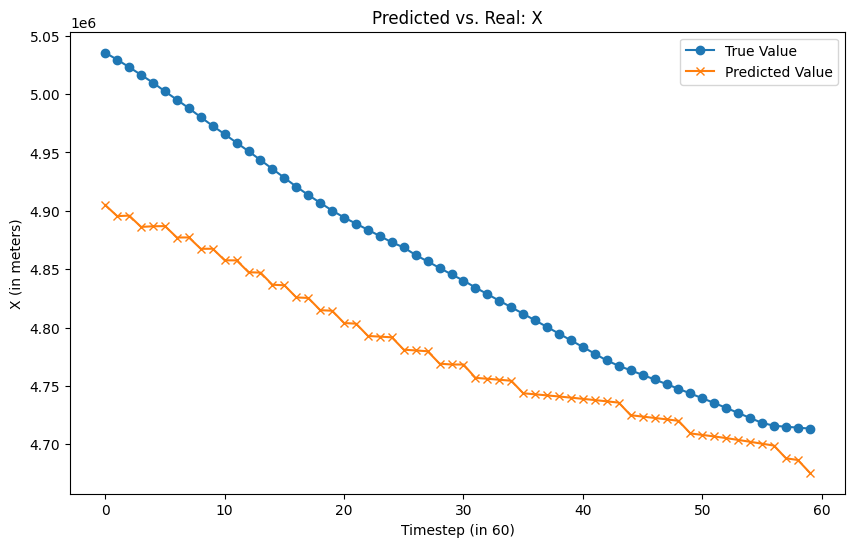

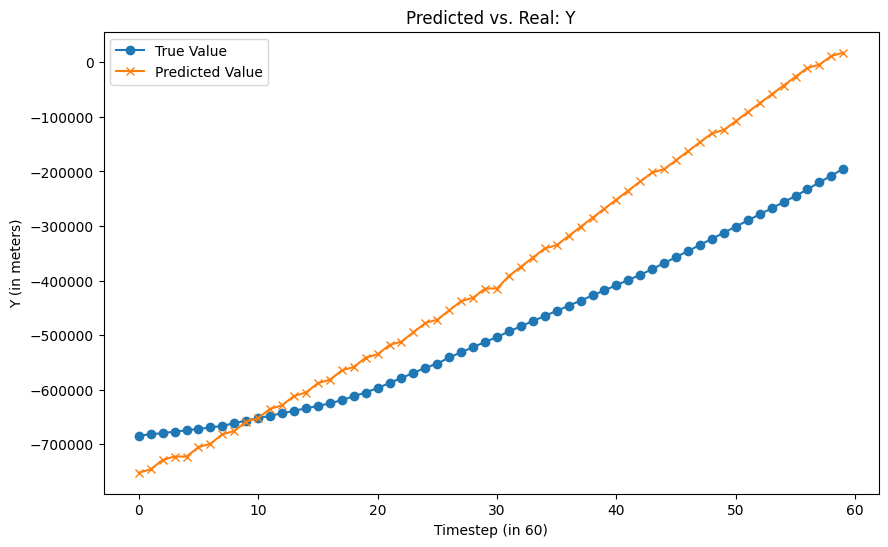

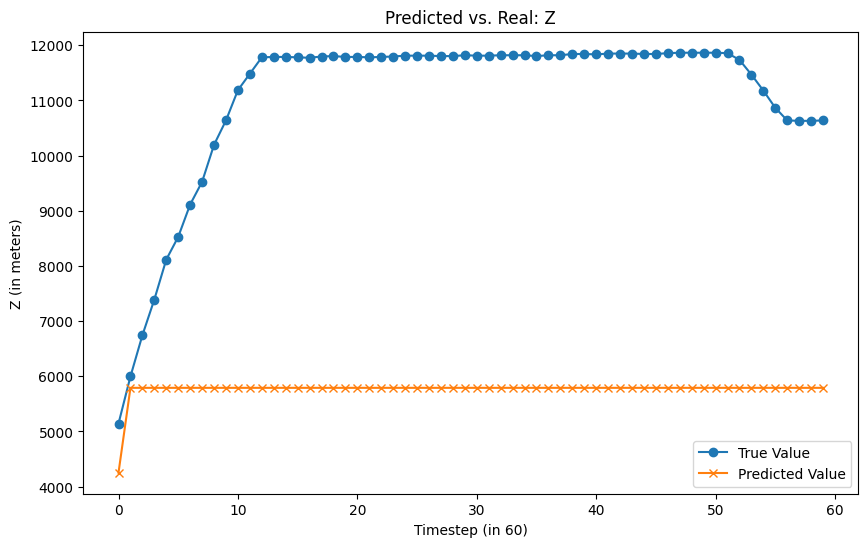

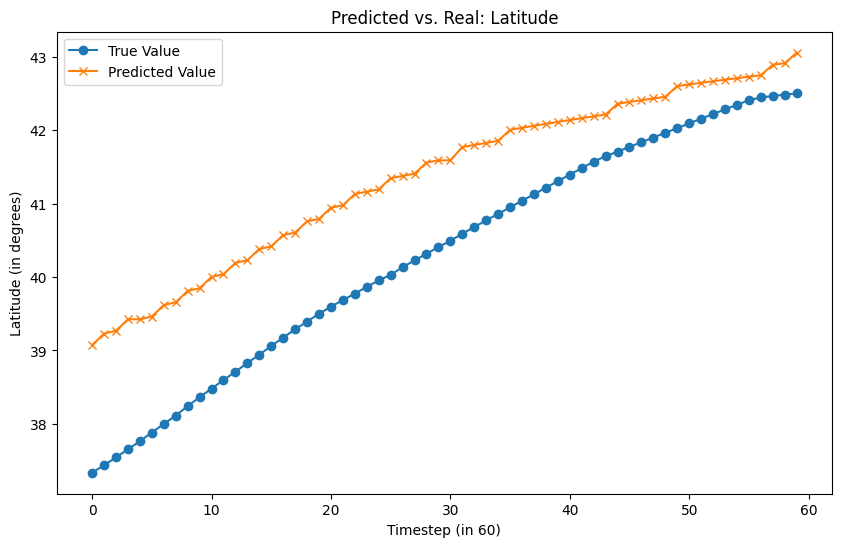

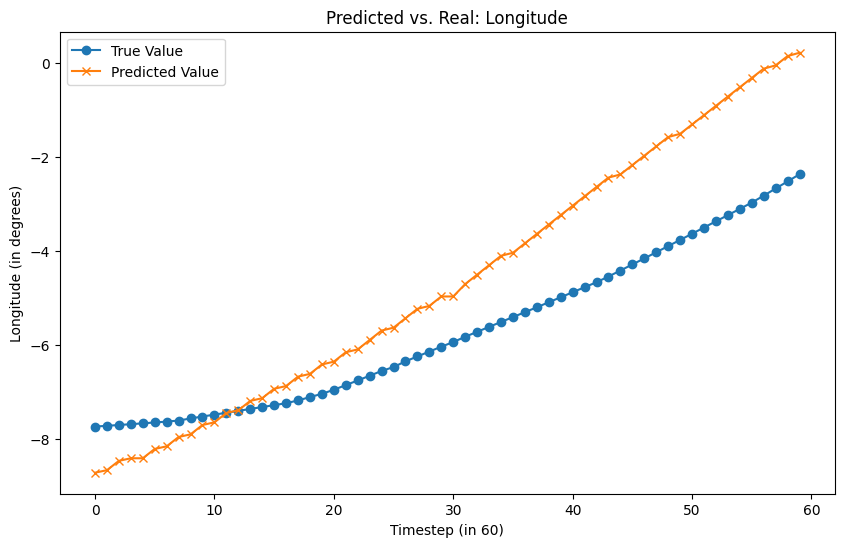

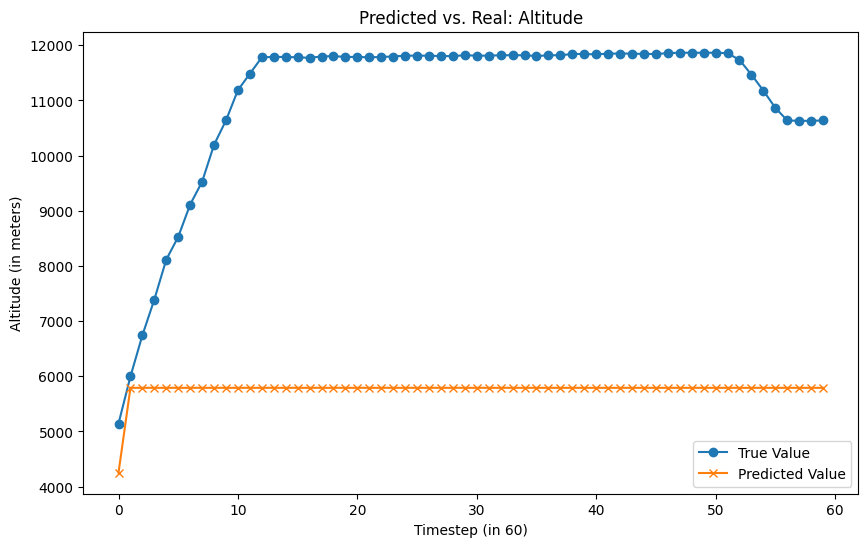

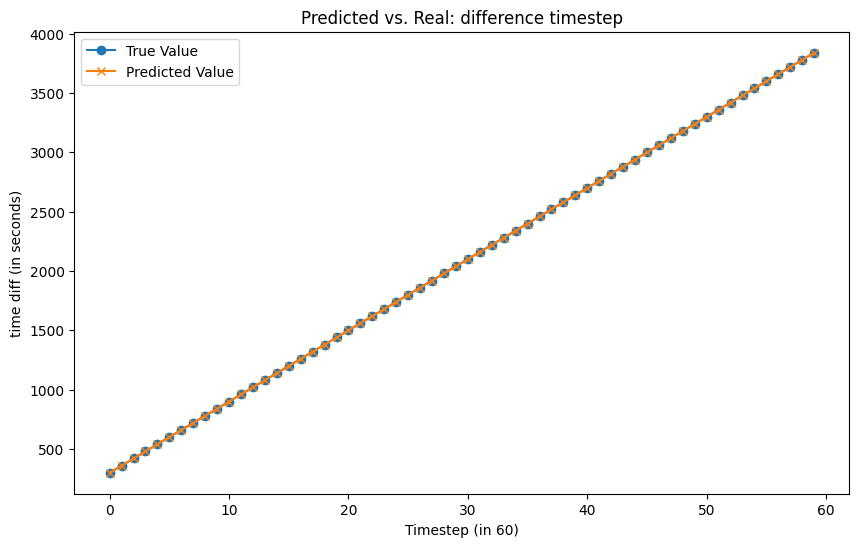

In [102]:
z_values = spatial_true_values[:, :, 2]
gps_alts = spatial_true_values[:, :, 5]
time_predictions = predictions[:, :, -1].astype(float)
time_targets = targets[:, :, -1].astype(float)
if "h3_cell" in TRAINING_COLUMNS:
  traj_predictions = predictions[:, :, [1,2,3]].astype(float)
  traj_targets = spatial_true_values[:, :, [3,4,5]].astype(float)
else:
  traj_predictions = predictions[:, :, :-1].astype(float)
  traj_targets = targets[:, :, :-1].astype(float)

if "x" in TRAINING_COLUMNS:
  spatial_results_ecef, _, _ = compute_spatial_errors(traj_predictions, traj_targets)
  spatial_results_geo, transformed_predictions, transformed_targets = compute_spatial_errors(traj_predictions, traj_targets, "ecef_2_geo", z_values)
  transformed_labels = ["Latitude (in degrees)", "Longitude (in degrees)", "Altitude (in meters)"]
  original_labels = ["X (in meters)", "Y (in meters)", "Z (in meters)"]
else:
  spatial_results_geo, _, _ = compute_spatial_errors(traj_predictions, traj_targets)
  spatial_results_ecef, transformed_predictions, transformed_targets = compute_spatial_errors(traj_predictions, traj_targets, "geo_2_ecef", gps_alts)
  original_labels = ["Latitude (in degrees)", "Longitude (in degrees)", "Altitude (in meters)"]
  transformed_labels = ["X (in meters)", "Y (in meters)", "Z (in meters)"]



time_errors = np.abs(time_targets - time_predictions)
squared_time_errors = time_errors ** 2
time_mae = np.mean(time_errors)
time_rmse = np.sqrt(np.mean(squared_time_errors))
time_displacement_errors = np.linalg.norm(time_predictions - time_targets, axis=-1)
time_ade = np.mean(time_displacement_errors)
final_time_displacement_errors = np.linalg.norm(
    time_predictions[:, -1] - time_targets[:, -1], axis=-1
)
time_fde = np.mean(final_time_displacement_errors)


sample_idx = 50
print("Sample Flight ID:", flight_ids[sample_idx])
print()
print("Temporal Errors:")
print("MAE:", time_mae)
print("RMSE:", time_rmse)
print("ADE:" ,time_ade)
print("FDE:", time_fde)
print("----------------------------")
print("Spatial Errors Geo:")
print("MAE per dimension:", spatial_results_geo["MAE"])
print("RMSE per dimension:", spatial_results_geo["RMSE"])
print("ADE:", spatial_results_geo["ADE"])
print("FDE:", spatial_results_geo["FDE"])
print()
print("----------------------------")
print("Spatial Errors ECEF:")
print("MAE per dimension:", spatial_results_ecef["MAE"])
print("RMSE per dimension:", spatial_results_ecef["RMSE"])
print("ADE:", spatial_results_ecef["ADE"])
print("FDE:", spatial_results_ecef["FDE"])
print()

for i, label in enumerate(transformed_labels):
    plot_pred_vs_true(
        pred=transformed_predictions[sample_idx][:, i],
        true=transformed_targets[sample_idx][:, i],
        y_label=label,
        title=f"Predicted vs. Real: {label.split()[0]}"
    )

for i, label in enumerate(original_labels):
    plot_pred_vs_true(
        pred=traj_predictions[sample_idx][:, i],
        true=traj_targets[sample_idx][:, i],
        y_label=label,
        title=f"Predicted vs. Real: {label.split()[0]}"
    )


plot_pred_vs_true(
    pred=time_predictions[sample_idx],
    true=time_targets[sample_idx],
    y_label="time diff (in seconds)",
    title=f"Predicted vs. Real: difference timestep"
)

In [103]:
#Addition to OG Code - the metrics above already aggregate over every flight in the test set
#(spatial_results_geo/ecef and time_mae/rmse/ade/fde are all means over axis=(0,1)), but they
#collapse straight to a single scalar and the plots only look at one flight (sample_idx). This
#cell keeps one row per test flight instead of collapsing to a mean, so the full distribution
#across the test set - not just its average - is visible, and outlier flights can be spotted.

#flight_ids repeats every id TGT_SEQ_LEN times (np.repeat in evaluate_model); every TGT_SEQ_LEN-th
#entry recovers one id per row, matching how predictions/targets/traj_predictions are indexed.
test_set_flight_ids = flight_ids[::TGT_SEQ_LEN]

original_displacement = np.linalg.norm(traj_predictions - traj_targets, axis=-1)                   # (N flights, TGT_SEQ_LEN)
transformed_displacement = np.linalg.norm(transformed_predictions - transformed_targets, axis=-1)  # (N flights, TGT_SEQ_LEN)
per_flight_time_error = np.abs(time_predictions - time_targets)                                    # (N flights, TGT_SEQ_LEN)

test_set_metrics = pd.DataFrame({
    "flight_id": test_set_flight_ids,
    "original_ade": original_displacement.mean(axis=1),
    "original_fde": original_displacement[:, -1],
    "transformed_ade": transformed_displacement.mean(axis=1),
    "transformed_fde": transformed_displacement[:, -1],
    "time_mae": per_flight_time_error.mean(axis=1),
    "time_fde": per_flight_time_error[:, -1],
})

print(f"Evaluated {len(test_set_metrics)} flights in the test set")
print()
test_set_metrics.describe()

Evaluated 124 flights in the test set



,original_ade,original_fde,transformed_ade,transformed_fde,time_mae,time_fde
count,124.000000,124.000000,1.240000e+02,1.240000e+02,124.000000,124.000000
mean,2293.810597,3880.348627,5.382034e+05,2.434106e+05,2.903226,2.903226
std,1569.005973,3966.158966,6.591781e+05,6.184126e+05,15.021621,15.021621
min,225.226335,38.127539,1.171344e+04,1.105241e+04,0.000000,0.000000
25%,1157.176322,1223.011921,1.893626e+05,6.030912e+04,0.000000,0.000000
50%,1762.916843,3006.090331,4.022351e+05,1.180721e+05,0.000000,0.000000
75%,3336.699705,5280.232435,7.617381e+05,2.402186e+05,0.000000,0.000000
max,8842.675856,35132.940877,5.168874e+06,5.064594e+06,120.000000,120.000000


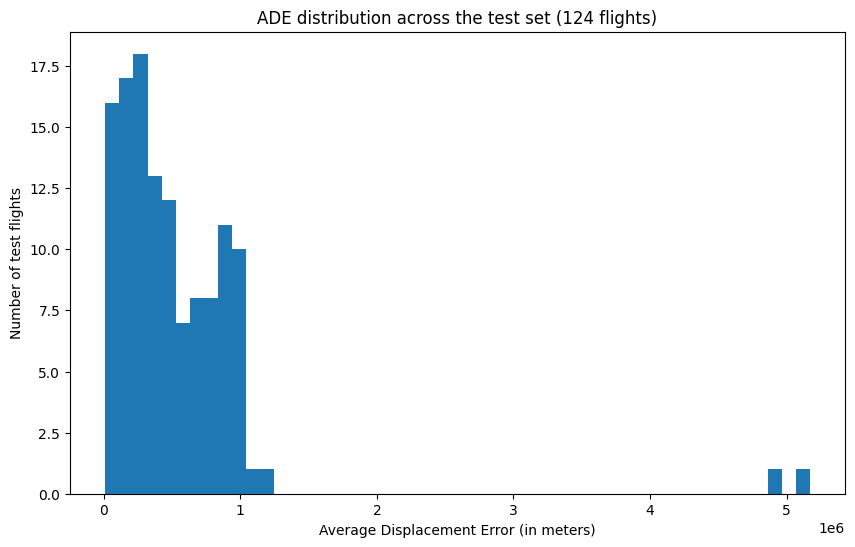

In [104]:
#Addition to OG Code - visualize the per-flight ADE distribution built above. transformed_ade is
#in the ecef domain (meters on all three axes), unlike original_ade which mixes degrees (lat/lon)
#with meters (altitude) in a single norm - same mixing spatial_results_geo["ADE"] already does
#above, just not flagged there. Using transformed_ade here keeps the plotted units unambiguous.
plt.figure(figsize=(10, 6))
plt.hist(test_set_metrics["transformed_ade"], bins=50)
plt.xlabel(f"Average Displacement Error ({transformed_labels[0].split('(')[1][:-1]})")
plt.ylabel("Number of test flights")
plt.title(f"ADE distribution across the test set ({len(test_set_metrics)} flights)")
plt.show()

In [105]:
def get_cell_distance(h_1, h_2, res=5):
    grid_len = h3.average_hexagon_edge_length(res, unit='m')
    distance = 0.0
    if h_1 != h_2:
        try:
            distance = h3.grid_distance(str(h_1), str(h_2))
        except:
            distance = np.nan

    horiz = np.sqrt(3) * grid_len * distance
    vert = (3 / 2) * grid_len * distance
    return np.sqrt(horiz**2 + horiz**2)


In [106]:
sample_flights_ids = test_flight_ids[:10] + ["ACA878_125_2024_10_10", "ACA878_117_2024_10_25"]

spatial_predictions = predictions[:, :, 0].flatten()
spatial_targets = targets[:, :, 0].flatten()

df_preds_tgts = pd.DataFrame({"flight_id": flight_ids, "tgt_h3_cell": spatial_targets, "pred_h3_cell": spatial_predictions})

In [107]:
df_preds_tgts["distance"] = df_preds_tgts.apply(lambda x: get_cell_distance(x.tgt_h3_cell, x.pred_h3_cell) , axis=1)
df_preds_tgts["distance_2"] = df_preds_tgts.apply(lambda x: get_cell_distance(x.tgt_h3_cell, x.pred_h3_cell)**2 , axis=1)

In [108]:
#MAE
df_preds_tgts["distance"].mean()

np.float64(850066.626604141)

In [109]:
#RMSE
np.sqrt(df_preds_tgts["distance_2"].mean())

np.float64(1107462.7811681032)

In [110]:
from pathlib import Path
df_tgts = df_preds_tgts[["flight_id", "tgt_h3_cell"]].rename(columns={"tgt_h3_cell": "h3_cell"})
df_preds = df_preds_tgts[["flight_id", "pred_h3_cell"]].rename(columns={"pred_h3_cell": "h3_cell"})

df_tgts["h3_geometry"] = df_tgts["h3_cell"].apply(lambda x: h3_to_polygon(x))
df_preds["h3_geometry"] = df_preds["h3_cell"].apply(lambda x: h3_to_polygon(x))

df_tgts["type"] = "true"
df_preds["type"] = "pred"

data = pd.concat([df_tgts, df_preds])
#Change to OG Code - merge widened to carry altitude/weather columns through, and both hover_data
#lists extended, so this map shows the same weather integration as the train/val/test map above.
#Weather columns only included when USE_WEATHER is on - they don't exist in `df` otherwise (same
#issue as the train/val/test map: _attach_weather_features is a no-op when USE_WEATHER is False).
hover_cols = ["flight_id", "timestamp", "gps_altitude"]
if USE_WEATHER:
    hover_cols += ["wind_speed_ms", "wind_direction_deg", "temperature_C"]

#Change to OG Code - dedupe columns before selecting: hover_cols already contains "flight_id",
#so prepending it again produced two identically-named "flight_id" columns in the selection,
#which made pd.merge's on=["flight_id", ...] key non-unique and raise ValueError.
merge_cols = list(dict.fromkeys(["flight_id", "h3_cell", "latitude", "longitude"] + hover_cols))

full_data = pd.merge(
    data,
    df[merge_cols],
    how="left",
    on=["flight_id", "h3_cell"]
)
full_data["id_type"] = full_data["flight_id"] + full_data["type"]

g_df, geojson = get_geojson_df(data)
h3_trajectories = px.choropleth_mapbox(
    full_data.loc[full_data.flight_id.isin(sample_flights_ids)],
    geojson=geojson,
    locations="h3_cell",
    color="id_type",
    hover_data=hover_cols,
    zoom=0,
    opacity=0.3,
)

lat_lon_trajectories = px.scatter_mapbox(
    df.loc[df.flight_id.isin(sample_flights_ids)],
    lat="latitude",
    lon="longitude",
    hover_data=hover_cols,
    color="flight_id",
    zoom=0
)


Path("./plots").mkdir(parents=True, exist_ok=True)
fig = go.Figure(h3_trajectories)
fig.add_traces(list(lat_lon_trajectories.select_traces()))
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.update_layout(title="Flights paths", mapbox_style="open-street-map")
fig.write_html("./plots/pred_tgt_trajs_noweather.html")  #Change to OG Code - _weather suffix so this run does not overwrite a non-weather plot

/tmp/ipykernel_265512/4052746171.py:34: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  h3_trajectories = px.choropleth_mapbox(
/tmp/ipykernel_265512/4052746171.py:44: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  lat_lon_trajectories = px.scatter_mapbox(
